# NB05: 유동인구 데이터 집계

**목적**: 12개월 행정동별 생활인구를 시간대/성별/연령별로 집계, 주문 잠재 고객군 식별

**입력**: `00_data/LOCAL__/LOCAL_PEOPLE_DONG_*.csv` (월별 12개)  
**출력**: `processed/flow_pop_agg.parquet` (동별 유동인구 집계)  
         `processed/flow_pop_hourly.parquet` (동별-시간대별 유동인구)

In [1]:
import pandas as pd
import numpy as np
import glob
from pathlib import Path

BASE = Path("..").resolve()
RAW  = BASE / "00_data"
OUT  = BASE / "processed"
CROSSWALK = OUT / "admin_code_crosswalk.csv"

# 생활인구 파일 탐색
fp_files = sorted(glob.glob(str(RAW / "LOCAL__" / "LOCAL_PEOPLE_DONG_*.csv")))
print(f"총 생활인구 파일: {len(fp_files)}개")

총 생활인구 파일: 12개


## 1. 전체 파일 로드 및 합치기

파일당 ~30만 행, UTF-8 BOM 인코딩

In [2]:
# 전체 파일 로드
dfs = []
for fpath in fp_files:
    for enc in ("utf-8-sig", "utf-8", "cp949"):
        try:
            df = pd.read_csv(fpath, encoding=enc, index_col=False)
            break
        except (UnicodeDecodeError, KeyError):
            continue
    # 파일명에서 연월 추출: LOCAL_PEOPLE_DONG_202501.csv → '202501'
    fname = Path(fpath).stem
    ym = fname.split("_")[3]
    df["ym"] = ym
    dfs.append(df)

df_fp = pd.concat(dfs, ignore_index=True)
print(f"전체 행 수: {len(df_fp):,}")
print(f"기간: {df_fp['ym'].min()} ~ {df_fp['ym'].max()}")
print(f"행정동 수: {df_fp['행정동코드'].nunique()}")
print(f"\n컬럼: {df_fp.columns.tolist()}")

전체 행 수: 3,693,812
기간: 202501 ~ 202512
행정동 수: 424

컬럼: ['기준일ID', '시간대구분', '행정동코드', '총생활인구수', '남자0세부터9세생활인구수', '남자10세부터14세생활인구수', '남자15세부터19세생활인구수', '남자20세부터24세생활인구수', '남자25세부터29세생활인구수', '남자30세부터34세생활인구수', '남자35세부터39세생활인구수', '남자40세부터44세생활인구수', '남자45세부터49세생활인구수', '남자50세부터54세생활인구수', '남자55세부터59세생활인구수', '남자60세부터64세생활인구수', '남자65세부터69세생활인구수', '남자70세이상생활인구수', '여자0세부터9세생활인구수', '여자10세부터14세생활인구수', '여자15세부터19세생활인구수', '여자20세부터24세생활인구수', '여자25세부터29세생활인구수', '여자30세부터34세생활인구수', '여자35세부터39세생활인구수', '여자40세부터44세생활인구수', '여자45세부터49세생활인구수', '여자50세부터54세생활인구수', '여자55세부터59세생활인구수', '여자60세부터64세생활인구수', '여자65세부터69세생활인구수', '여자70세이상생활인구수', 'ym', '?"기준일ID"']


In [3]:
# 컬럼 영문 리네임
rename_dict = {
    "남자0세부터9세생활인구수":   "M_00_CNT",
    "남자10세부터14세생활인구수": "M_10_CNT",
    "남자15세부터19세생활인구수": "M_15_CNT",
    "남자20세부터24세생활인구수": "M_20_CNT",
    "남자25세부터29세생활인구수": "M_25_CNT",
    "남자30세부터34세생활인구수": "M_30_CNT",
    "남자35세부터39세생활인구수": "M_35_CNT",
    "남자40세부터44세생활인구수": "M_40_CNT",
    "남자45세부터49세생활인구수": "M_45_CNT",
    "남자50세부터54세생활인구수": "M_50_CNT",
    "남자55세부터59세생활인구수": "M_55_CNT",
    "남자60세부터64세생활인구수": "M_60_CNT",
    "남자65세부터69세생활인구수": "M_65_CNT",
    "남자70세이상생활인구수":     "M_70_CNT",
    "여자0세부터9세생활인구수":   "F_00_CNT",
    "여자10세부터14세생활인구수": "F_10_CNT",
    "여자15세부터19세생활인구수": "F_15_CNT",
    "여자20세부터24세생활인구수": "F_20_CNT",
    "여자25세부터29세생활인구수": "F_25_CNT",
    "여자30세부터34세생활인구수": "F_30_CNT",
    "여자35세부터39세생활인구수": "F_35_CNT",
    "여자40세부터44세생활인구수": "F_40_CNT",
    "여자45세부터49세생활인구수": "F_45_CNT",
    "여자50세부터54세생활인구수": "F_50_CNT",
    "여자55세부터59세생활인구수": "F_55_CNT",
    "여자60세부터64세생활인구수": "F_60_CNT",
    "여자65세부터69세생활인구수": "F_65_CNT",
    "여자70세이상생활인구수":     "F_70_CNT",
    "시간대구분": "TIME_CD",
    "총생활인구수": "TOTAL_POP_ORG",
}

df_fp = df_fp.rename(columns=rename_dict)
# 기준일ID 컬럼은 분석에 불필요 — 드롭
df_fp = df_fp.drop(columns=["기준일ID"], errors="ignore")
print(f"리네임 후 컬럼: {df_fp.columns.tolist()}")

리네임 후 컬럼: ['TIME_CD', '행정동코드', 'TOTAL_POP_ORG', 'M_00_CNT', 'M_10_CNT', 'M_15_CNT', 'M_20_CNT', 'M_25_CNT', 'M_30_CNT', 'M_35_CNT', 'M_40_CNT', 'M_45_CNT', 'M_50_CNT', 'M_55_CNT', 'M_60_CNT', 'M_65_CNT', 'M_70_CNT', 'F_00_CNT', 'F_10_CNT', 'F_15_CNT', 'F_20_CNT', 'F_25_CNT', 'F_30_CNT', 'F_35_CNT', 'F_40_CNT', 'F_45_CNT', 'F_50_CNT', 'F_55_CNT', 'F_60_CNT', 'F_65_CNT', 'F_70_CNT', 'ym', '?"기준일ID"']


In [4]:
# 크로스워크 로드 (NaN 행 제거 후 int 변환)
crosswalk = pd.read_csv(CROSSWALK)
crosswalk = crosswalk.dropna(subset=["CSV_ADMI_CD"])
crosswalk["CSV_ADMI_CD"] = crosswalk["CSV_ADMI_CD"].astype(int).astype(str)
crosswalk["SHP_ADM_CD"] = crosswalk["SHP_ADM_CD"].astype(int).astype(str)
print(f"크로스워크 로드 완료: {len(crosswalk)} 동")

# 행정동코드 float → int → str 변환
df_fp["행정동코드"] = pd.to_numeric(df_fp["행정동코드"], errors="coerce")
df_fp = df_fp.dropna(subset=["행정동코드"])
df_fp["행정동코드"] = df_fp["행정동코드"].astype(int).astype(str)

# 매핑 (inner join → 서울 동만 유지)
df_fp = pd.merge(
    df_fp,
    crosswalk,
    left_on="행정동코드",
    right_on="CSV_ADMI_CD",
    how="inner",
)

print(f"매핑 완료! 최종 데이터 행 수: {len(df_fp):,}")
print(f"매핑된 구 목록: {sorted(df_fp['GU_NM'].unique())}")
display(df_fp.head())

크로스워크 로드 완료: 418 동
매핑 완료! 최종 데이터 행 수: 3,554,424
매핑된 구 목록: ['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']


,TIME_CD,행정동코드,TOTAL_POP_ORG,M_00_CNT,M_10_CNT,M_15_CNT,M_20_CNT,M_25_CNT,M_30_CNT,M_35_CNT,...,F_55_CNT,F_60_CNT,F_65_CNT,F_70_CNT,ym,"?""기준일ID""",SHP_ADM_CD,CSV_ADMI_CD,GU_NM,DONG_NM
0,0,11110515,13959.2812,481.4116,306.7564,478.2017,357.3834,397.8554,361.7199,474.9342,...,572.4571,473.0731,344.2641,1022.5939,202501,NaN,11010720,11110515,종로구,청운효자동
1,0,11110530,14230.5596,343.2194,152.5419,449.6299,551.2311,564.9371,466.4311,546.0382,...,553.9168,499.1170,270.3996,873.3966,202501,NaN,11010530,11110530,종로구,사직동
2,0,11110540,3409.7726,58.5555,44.8674,107.5601,273.7226,103.7417,96.4308,131.6848,...,150.1466,132.2848,93.3248,256.0581,202501,NaN,11010540,11110540,종로구,삼청동
3,0,11110550,12816.3213,310.6309,240.8591,377.7566,417.1609,338.8140,330.5938,459.8556,...,617.7934,455.7202,381.3082,1082.2851,202501,NaN,11010550,11110550,종로구,부암동
4,0,11110560,18662.7186,638.8311,462.0873,484.2466,617.8459,461.8934,389.0284,586.5398,...,974.9772,893.7486,565.8544,1770.1419,202501,NaN,11010560,11110560,종로구,평창동


## 2. 성별/연령대 합산 → 동별-시간대 총 유동인구

In [5]:
# 성별/연령 컬럼 식별
male_cols   = [c for c in df_fp.columns if c.startswith("M_") and c.endswith("_CNT")]
female_cols = [c for c in df_fp.columns if c.startswith("F_") and c.endswith("_CNT")]
pop_cols = male_cols + female_cols

print(f"남성 연령대: {male_cols}")
print(f"여성 연령대: {female_cols}")

df_fp["total_pop"]  = df_fp[pop_cols].sum(axis=1)
df_fp["male_pop"]   = df_fp[male_cols].sum(axis=1)
df_fp["female_pop"] = df_fp[female_cols].sum(axis=1)

# 배달 주문 핵심 연령대 (20~40대) 유동인구
young_cols = [c for c in pop_cols if any(
    c.startswith(f"{g}_{a}") for g in ["M", "F"] for a in ["20", "25", "30", "35", "40", "45"]
)]
df_fp["young_pop"] = df_fp[young_cols].sum(axis=1)

print(f"\n배달 핵심 연령(20~40대) 컬럼: {len(young_cols)}개")
print(f"전체 유동인구 평균: {df_fp['total_pop'].mean():,.0f}")
print(f"20~40대 유동인구 비율: {df_fp['young_pop'].sum() / df_fp['total_pop'].sum():.1%}")

남성 연령대: ['M_00_CNT', 'M_10_CNT', 'M_15_CNT', 'M_20_CNT', 'M_25_CNT', 'M_30_CNT', 'M_35_CNT', 'M_40_CNT', 'M_45_CNT', 'M_50_CNT', 'M_55_CNT', 'M_60_CNT', 'M_65_CNT', 'M_70_CNT']
여성 연령대: ['F_00_CNT', 'F_10_CNT', 'F_15_CNT', 'F_20_CNT', 'F_25_CNT', 'F_30_CNT', 'F_35_CNT', 'F_40_CNT', 'F_45_CNT', 'F_50_CNT', 'F_55_CNT', 'F_60_CNT', 'F_65_CNT', 'F_70_CNT']

배달 핵심 연령(20~40대) 컬럼: 12개
전체 유동인구 평균: 23,811
20~40대 유동인구 비율: 49.5%


## 3. 동별 유동인구 밀집도 지수 산출 (최근 12개월)

In [6]:
# 최근 12개월 필터
recent_months = sorted(df_fp["ym"].unique())[-12:]
recent = df_fp[df_fp["ym"].isin(recent_months)]

# 동별 집계
pop_by_dong = (
    recent.groupby("CSV_ADMI_CD")
    .agg(
        avg_daily_total=("total_pop", "mean"),
        avg_daily_young=("young_pop", "mean"),
        peak_hour_pop=("total_pop", "max"),
        dong_nm=("DONG_NM", "first"),
    )
    .reset_index()
)

# 0-1 정규화
for col in ["avg_daily_total", "avg_daily_young"]:
    vmin, vmax = pop_by_dong[col].min(), pop_by_dong[col].max()
    pop_by_dong[f"{col}_norm"] = (pop_by_dong[col] - vmin) / (vmax - vmin)

# 유동인구 밀집도 지수 (전체 0.5 + 2040대 0.5)
pop_by_dong["flow_pop_index"] = (
    0.5 * pop_by_dong["avg_daily_total_norm"]
    + 0.5 * pop_by_dong["avg_daily_young_norm"]
)

print(f"동별 유동인구 지수 (최근 12개월: {recent_months[0]}~{recent_months[-1]}):")
print(pop_by_dong.nlargest(10, "flow_pop_index")[["CSV_ADMI_CD", "dong_nm", "avg_daily_total", "flow_pop_index"]])

동별 유동인구 지수 (최근 12개월: 202501~202512):
    CSV_ADMI_CD dong_nm  avg_daily_total  flow_pop_index
353    11680640    역삼1동    100547.020246        1.000000
273    11560540     여의동     98417.139501        0.911496
200    11440660     서교동     71538.612789        0.691166
261    11545510     가산동     60948.453405        0.582328
327    11650530    서초3동     65217.061300        0.562105
181    11410585     신촌동     56354.962757        0.540785
405    11740685      길동     60285.137792        0.470169
38     11170625    한강로동     51711.738301        0.468989
354    11680650    역삼2동     53604.815785        0.448678
168    11380570     대조동     55427.407654        0.443469


## 4. 시간대별 유동인구 패턴

In [7]:
# 동별-시간대별 유동인구
hourly_pop = (
    recent.groupby(["CSV_ADMI_CD", "TIME_CD"])
    .agg(avg_total_pop=("total_pop", "mean"), avg_young_pop=("young_pop", "mean"))
    .reset_index()
)

print(f"시간대별 유동인구 패턴: {len(hourly_pop)} rows")
print(f"시간대(TIME_CD) 범위: {sorted(hourly_pop['TIME_CD'].unique())}")

시간대별 유동인구 패턴: 9792 rows
시간대(TIME_CD) 범위: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## 5. 시각 검증 + 저장

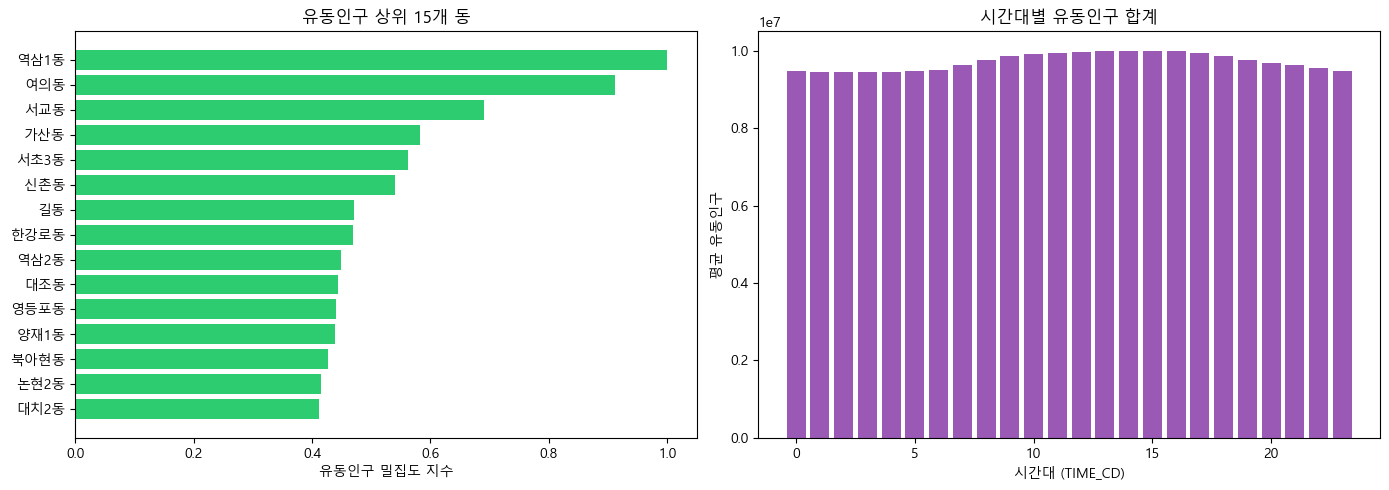

In [8]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 동별 유동인구 지수 상위 15개
top15 = pop_by_dong.nlargest(15, "flow_pop_index")
axes[0].barh(top15["dong_nm"][::-1], top15["flow_pop_index"][::-1], color="#2ecc71")
axes[0].set_xlabel("유동인구 밀집도 지수")
axes[0].set_title("유동인구 상위 15개 동")

# 오른쪽: 시간대별 전체 유동인구 패턴
hourly_total = hourly_pop.groupby("TIME_CD")["avg_total_pop"].sum()
axes[1].bar(hourly_total.index, hourly_total.values, color="#9b59b6")
axes[1].set_xlabel("시간대 (TIME_CD)")
axes[1].set_ylabel("평균 유동인구")
axes[1].set_title("시간대별 유동인구 합계")

plt.tight_layout()
plt.show()

In [9]:
# 저장
OUT.mkdir(parents=True, exist_ok=True)
pop_by_dong.to_parquet(OUT / "flow_pop_agg.parquet", index=False)
hourly_pop.to_parquet(OUT / "flow_pop_hourly.parquet", index=False)

print("저장 완료:")
print(f"  - flow_pop_agg.parquet ({len(pop_by_dong)} rows) - 동별 유동인구 지수")
print(f"  - flow_pop_hourly.parquet ({len(hourly_pop)} rows) - 동별-시간대별 유동인구")

저장 완료:
  - flow_pop_agg.parquet (408 rows) - 동별 유동인구 지수
  - flow_pop_hourly.parquet (9792 rows) - 동별-시간대별 유동인구
